# Spam Email Classification
This project uses Machine Learning to classify emails as spam or not spam.
Steps:
1. Import libraries
2. Load dataset
3. Data exploration
4. Feature extraction using TF-IDF
5. Train model
6. Evaluate model

In [16]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Load dataset
df = pd.read_csv("emails.csv")
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [18]:
df.shape

(5728, 2)

In [19]:
df.columns

Index(['text', 'spam'], dtype='str')

In [20]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [21]:
df['spam'].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

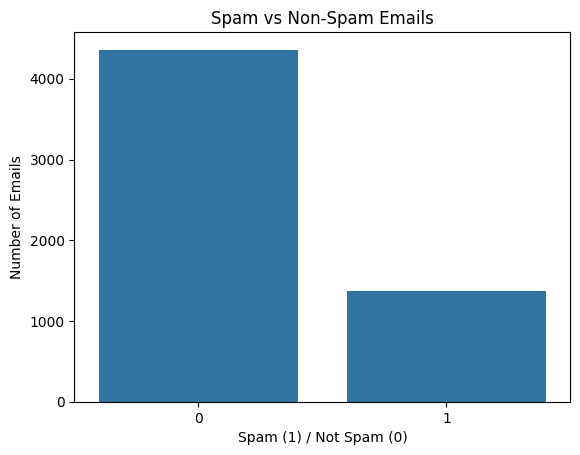

In [22]:
sns.countplot(x='spam', data=df)
plt.title("Spam vs Non-Spam Emails")
plt.xlabel("Spam (1) / Not Spam (0)")
plt.ylabel("Number of Emails")
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
X = df['text']
y = df['spam']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [25]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [26]:
y_pred = model.predict(X_test_vec)

In [27]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8926701570680629


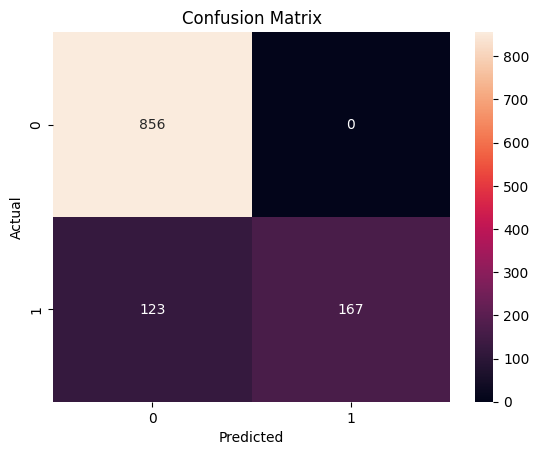

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       856
           1       1.00      0.58      0.73       290

    accuracy                           0.89      1146
   macro avg       0.94      0.79      0.83      1146
weighted avg       0.91      0.89      0.88      1146

